# <center>Problem Statement</center>

The objective of this project is to build an Anime Recommendation System that suggests relevant anime to users based on their preferences and behavior.

With a large number of anime available, users often find it difficult to discover content that matches their interests. This system aims to improve user experience by providing personalized and meaningful recommendations.

The recommendation system will be built using:
- Popularity-Based Recommendation
- Content-Based Filtering
- Collaborative Filtering

# <center>Data Overview</center>

This project uses two datasets:

1. Anime Dataset (anime.csv)

This dataset contains information about each anime such as genre, type, and ratings.

2. Rating Dataset (rating.csv)

This dataset contains user interactions, i.e., which user rated which anime.

# <center>Data Dictionary</center>

Anime Dataset(anime.csv)

|Column|Description|
|---|---
|anime_id|Unique identifier for each anime|
|name|Name of the anime|
|genre|List of genres (comma-separated)|
|type|Type of anime (TV, Movie, OVA, etc.)|
|episodes|Number of episodes|
|rating|Average rating of the anime (out of 10)|
|members|Number of community members that are in this anime's group|

Rating Dataset(rating.csv)

|Column|Description|
|---|---
|user_id|Unique identifier for each user|
|anime_id|Anime watched/rated by the user|
|rating|Rating given by the user (1–10) Note:-1 is the rating that user watched the anime but didn't rate it.|

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Text processing (for content-based filtering)
from sklearn.feature_extraction.text import TfidfVectorizer

# Similarity calculation
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# <center>Data Loading, Understanding and Cleaning</center>

In [2]:
anime_df = pd.read_csv('anime.csv')
rating_df = pd.read_csv('rating.csv')
print("anime_df shape: ",anime_df.shape)
print("rating_df shape: ",rating_df.shape)

anime_df shape:  (12294, 7)
rating_df shape:  (7813737, 3)


In [3]:
anime_df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
anime_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 1.3 MB


In [5]:
# Changing the episodes dtype to numeric
anime_df["episodes"]=pd.to_numeric(anime_df['episodes'], errors='coerce')
anime_df["episodes"].dtype

dtype('float64')

In [6]:
anime_df.describe()

,anime_id,episodes,rating,members
count,12294.000000,11954.000000,12064.000000,1.229400e+04
mean,14058.221653,12.382550,6.473902,1.807134e+04
std,11455.294701,46.865352,1.026746,5.482068e+04
min,1.000000,1.000000,1.670000,5.000000e+00
25%,3484.250000,1.000000,5.880000,2.250000e+02
50%,10260.500000,2.000000,6.570000,1.550000e+03
75%,24794.500000,12.000000,7.180000,9.437000e+03
max,34527.000000,1818.000000,10.000000,1.013917e+06


In [7]:
anime_df.describe(exclude="number")

,name,genre,type
count,12294,12232,12269
unique,12292,3264,6
top,Saru Kani Gassen,Hentai,TV
freq,2,823,3787


In [8]:
anime_df.duplicated(subset='anime_id').sum()

np.int64(0)

In [9]:
# Checking for nulls
anime_df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes    340
rating      230
members       0
dtype: int64

In [10]:
# Fill text columns with empty string
anime_df['genre'] = anime_df['genre'].fillna('')
anime_df['type'] = anime_df['type'].fillna('')
anime_df["episodes"]  = anime_df["episodes"].fillna(anime_df["episodes"].median())
anime_df["rating"] = anime_df["rating"].fillna(anime_df["rating"].median())

In [11]:
anime_df

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1.0,4.15,211
12290,5543,Under World,Hentai,OVA,1.0,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4.0,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1.0,4.98,175


In [12]:
rating_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


In [13]:
rating_df.describe()

,user_id,anime_id,rating
count,7.813737e+06,7.813737e+06,7.813737e+06
mean,3.672796e+04,8.909072e+03,6.144030e+00
std,2.099795e+04,8.883950e+03,3.727800e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01


In [14]:
rating_df.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [15]:
rating_df.duplicated(subset=['user_id', 'anime_id']).sum()

np.int64(7)

In [16]:
rating_df[rating_df.duplicated(subset=['user_id', 'anime_id'], keep=False)]

,user_id,anime_id,rating
4499243,42653,1575,8
4499244,42653,2001,8
4499255,42653,11757,8
4499258,42653,16498,8
4499261,42653,20507,7
4499263,42653,22319,8
4499266,42653,23283,8
4499286,42653,1575,6
4499288,42653,2001,10
4499307,42653,11757,5


In [17]:
rating_df = rating_df.groupby(['user_id','anime_id'])['rating'].mean().reset_index()
rating_df

,user_id,anime_id,rating
0,1,20,-1.0
1,1,24,-1.0
2,1,79,-1.0
3,1,226,-1.0
4,1,241,-1.0
...,...,...,...
7813725,73515,16512,7.0
7813726,73515,17187,9.0
7813727,73515,22145,10.0
7813728,73516,790,9.0


In [18]:
rating_df.duplicated().sum()

np.int64(0)

# <center>EDA</center>

In [19]:
# Top 10 popular anime based on community members
anime_df.sort_values(by='members', ascending=False)[['name', 'members']].head(10)


,name,members
40,Death Note,1013917
86,Shingeki no Kyojin,896229
804,Sword Art Online,893100
1,Fullmetal Alchemist: Brotherhood,793665
159,Angel Beats!,717796
19,Code Geass: Hangyaku no Lelouch,715151
841,Naruto,683297
3,Steins;Gate,673572
445,Mirai Nikki (TV),657190
131,Toradora!,633817


In [20]:
# Top 10 rated Anime
anime_df.sort_values(by='rating', ascending=False)[['name', 'rating']].head(10)

,name,rating
10464,Taka no Tsume 8: Yoshida-kun no X-Files,10.00
10400,Spoon-hime no Swing Kitchen,9.60
9595,Mogura no Motoro,9.50
0,Kimi no Na wa.,9.37
9078,Kahei no Umi,9.33
1,Fullmetal Alchemist: Brotherhood,9.26
10786,Yakusoku: Africa Mizu to Midori,9.25
2,Gintama°,9.25
3,Steins;Gate,9.17
4,Gintama&#039;,9.16


In [21]:
# Genre Distribution
anime_df['genre'].str.split(',').explode().value_counts().head(10)

genre
Comedy       3193
Action       2845
 Sci-Fi      1986
 Fantasy     1815
 Shounen     1663
Adventure    1457
 Comedy      1452
 Romance     1371
 Kids        1213
 School      1170
Name: count, dtype: int64

In [22]:
# Types Distribtion
anime_df['type'].value_counts()

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
             25
Name: count, dtype: int64

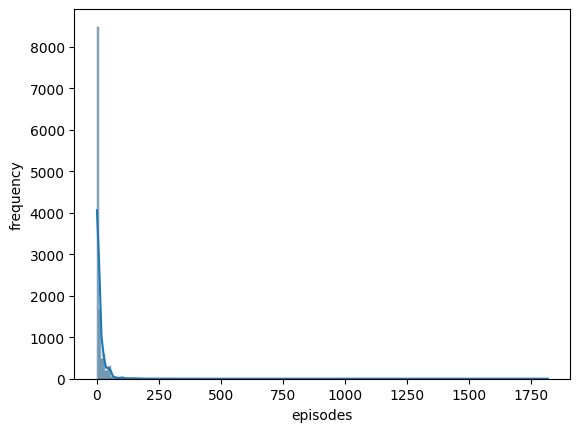

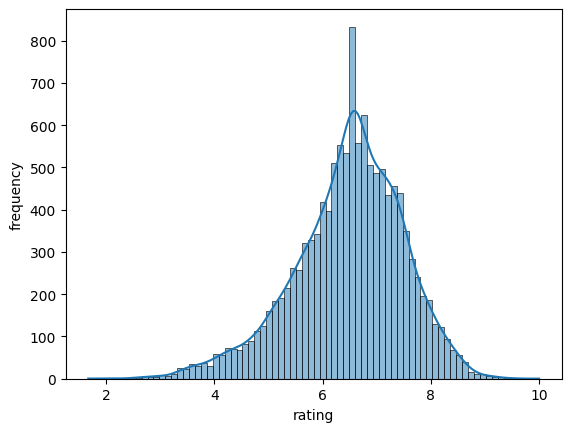

In [23]:
# Episodes, rating column distribution
for column in ['episodes', 'rating']:
    sns.histplot(anime_df[column], kde=True)
    plt.xlabel(column)
    plt.ylabel("frequency")
    plt.show()

In [24]:
print(f"we have {rating_df['user_id'].nunique()} user_id in the rating.csv")
print(f"we have {rating_df['anime_id'].nunique()} anime_id in the rating.csv")

we have 73515 user_id in the rating.csv
we have 11200 anime_id in the rating.csv


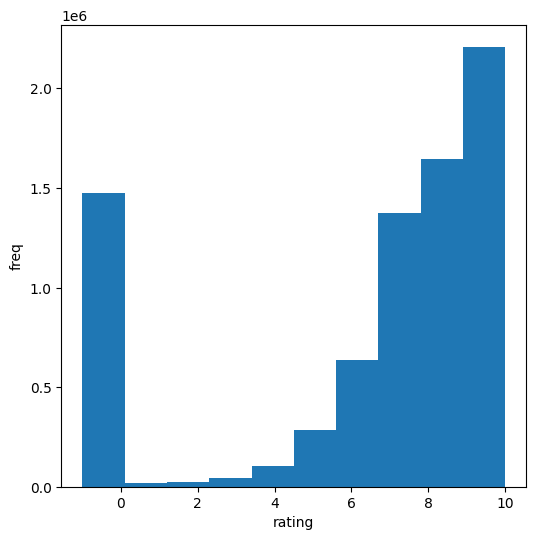

In [25]:
plt.figure(figsize=(6,6))
plt.hist(rating_df['rating'], bins=10)
plt.xlabel('rating')
plt.ylabel('freq')
plt.show()

In [26]:
# Removing the -1 ratings rows from the datset
rating_df = rating_df[rating_df['rating'] != -1]

In [27]:
rating_df['user_id'].value_counts()

user_id
42635    3747
53698    2905
57620    2689
59643    2632
51693    2621
         ... 
73465       1
73477       1
73496       1
73509       1
73514       1
Name: count, Length: 69600, dtype: int64

In [28]:
rating_df['anime_id'].value_counts()

anime_id
1535     34226
11757    26309
16498    25289
1575     24125
6547     23565
         ...  
23585        1
33659        1
30738        1
8723         1
8749         1
Name: count, Length: 9927, dtype: int64

In [29]:
print(rating_df.shape)

user_counts = rating_df['user_id'].value_counts()

anime_counts = rating_df['anime_id'].value_counts()


# After filtering
filtered_df = rating_df[
    rating_df['user_id'].isin(user_counts[user_counts > 100].index) &
    rating_df['anime_id'].isin(anime_counts[anime_counts > 100].index)
]

print(filtered_df.shape)

(6337234, 3)
(4621635, 3)


# <center>Popularity Based</center>

In [30]:
anime_df['rating_norm'] = anime_df['rating'] / anime_df['rating'].max()
anime_df['members_norm'] = anime_df['members'] / anime_df['members'].max()
anime_df['norm_score'] = anime_df['rating_norm'] * 0.6 + anime_df['members_norm'] * 0.4

In [31]:
C = anime_df['rating'].mean()
m = anime_df['members'].quantile(0.90)

def weighted_rating(x, m=m, C=C):
    v = x['members']
    R = x['rating']
    return (v/(v+m))*R + (m/(v+m))*C

anime_df['weighted_score'] = anime_df.apply(weighted_rating, axis=1)

In [32]:
# 50% each (adjustable)
anime_df['final_score'] = 0.5 * anime_df['norm_score'] + 0.5 * (anime_df['weighted_score']/10)  # divide by 10 to normalize weighted_score

In [33]:
top_10 = anime_df.sort_values('final_score', ascending=False)[['name', 'rating', 'members', 'final_score']]
top_10.head(10)

,name,rating,members,final_score
40,Death Note,8.71,1013917,0.892033
1,Fullmetal Alchemist: Brotherhood,9.26,793665,0.889855
3,Steins;Gate,9.17,673572,0.857996
86,Shingeki no Kyojin,8.54,896229,0.855031
19,Code Geass: Hangyaku no Lelouch,8.83,715151,0.840471
13,Code Geass: Hangyaku no Lelouch R2,8.98,572888,0.822250
159,Angel Beats!,8.39,717796,0.807120
23,One Punch Man,8.82,552458,0.805712
29,Tengen Toppa Gurren Lagann,8.78,562962,0.804886
10,Clannad: After Story,9.06,456749,0.803263


# <center>Content Based Filtering</center>

In [ ]:
def recommend_content_based(anime_name, top_n=10):
    try:
        idx = anime_df[anime_df['name'] == anime_name].index[0]
    except IndexError:
        print(f"Anime '{anime_name}' not found")
        return None
    
    sim_scores = list(enumerate(cosine_similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    
    anime_indices = [i[0] for i in sim_scores]
    similarity_values = [i[1] for i in sim_scores]
    
    result = anime_df.iloc[anime_indices][['name', 'genre', 'rating']].copy()
    result['similarity_score'] = similarity_values  # ← Added!
    
    return result

# <center>Collaborative Filtering</center>

In [51]:
rating_matrix = filtered_df.pivot(index='user_id', columns='anime_id', values='rating').fillna(0)

item_sim = cosine_similarity(rating_matrix.T)

item_sim_df = pd.DataFrame(item_sim, index=rating_matrix.columns, columns=rating_matrix.columns)

# Example for item-item:
def recommend_collaborative_based(user_id, top_n=10):
    user_ratings = rating_matrix.loc[user_id]
    rated_animes = user_ratings[user_ratings > 0].index.tolist()  # already rated

    # Compute mean similarity scores for items not yet rated
    sim_scores = item_sim_df[rated_animes].mean(axis=1)
    sim_scores = sim_scores.drop(rated_animes)  # exclude already rated
    top_animes = sim_scores.nlargest(top_n)
    
    # Merge with anime names
    result = anime_df[anime_df['anime_id'].isin(top_animes.index)].copy()
    result['predicted_score'] = result['anime_id'].map(top_animes)
    result = result.set_index('anime_id').loc[top_animes.index].reset_index()
    
    return result[['name', 'genre', 'rating', 'predicted_score']]